# 02 — Farm Microclimate Clustering: Kona vs Kaʻu

K-means clustering run **separately** for each region to find natural environmental
archetypes within Kona and Kaʻu. Results compared side-by-side.

**Questions:**
- How many distinct microclimate types exist within Kona? Within Kaʻu?
- Do the cluster profiles (wet/dry, high/low elevation) match what’s known about the belts?

> Kaʻu n=62 — cluster results should be interpreted cautiously at small K.


In [1]:
import pandas as pd
import geopandas as gpd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import matplotlib.patches as mpatches
from matplotlib.colors import LinearSegmentedColormap, ListedColormap
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score
import warnings
warnings.filterwarnings('ignore')

DATA = '../data'
IMG  = '../img'
BG   = 'white'
SPLIT_LON = -155.7279
CLUSTER_COLORS = ['#7eb8f7', '#f7a07e', '#7ef7b8', '#f7d07e', '#d07ef7']

def clip_cmap(name, lo=0.0, hi=0.9):
    base = cm.get_cmap(name)
    return LinearSegmentedColormap.from_list(f'{name}_clip', base(np.linspace(lo, hi, 256)))


/home/simonhans/anaconda3/lib/python3.7/site-packages/geopandas/_compat.py:115: UserWarning: The Shapely GEOS version (3.11.4-CAPI-1.17.4) is incompatible with the GEOS version PyGEOS was compiled with (3.10.4-CAPI-1.16.2). Conversions between both will be slow.
  shapely_geos_version, geos_capi_version_string


In [2]:
# ── Load and split by region ──────────────────────────────────────────────────
df = pd.read_pickle(f'{DATA}/df.pkl')
df = df.drop(columns = 'cold_months')
TOPO_COLS = [
    'elev_mean', 'elev_dev_mean', 'slope_max',
    'aspect_sin', 'aspect_cos', 'curve_mean',
    'total_relief', 'local_relief', 'dist_coast_m',
]
CLIMATE_COLS = [
    'temp_mean', 'temp_range', 'gdd', #'cold_months',
    'precip_annual', 'precip_dry_frac', 'wind_speed_mean',
]
SOIL_COLS  = [
    'drain_ord', 'restrictiondepth_cm', 'awc_mean',
    'ph_0_30cm', 'om_0_30cm',
    'sand_0_30cm', 'silt_0_30cm', 'clay_0_30cm', 'cec_0_30cm',
]
SOIL_COLS = [c for c in SOIL_COLS if c in df.columns]  # guard: new cols need df.pkl regen
FEAT_COLS = TOPO_COLS + CLIMATE_COLS + SOIL_COLS + ['ndvi_median']

kona_df = df[df.region == 'kona'][['plot_id'] + FEAT_COLS].dropna().reset_index(drop=True)
kau_df  = df[df.region == 'kau' ][['plot_id'] + FEAT_COLS].dropna().reset_index(drop=True)

print(f'Kona: {len(kona_df)} cells  \u00d7  {len(FEAT_COLS)} features')
print(f"Kaʻu: {len(kau_df)} cells  \u00d7  {len(FEAT_COLS)} features")

scalers = {}
Xs_dict = {}
for reg, sub in [('kona', kona_df), ('kau', kau_df)]:
    sc = StandardScaler()
    Xs_dict[reg] = sc.fit_transform(sub[FEAT_COLS].values)
    scalers[reg] = sc


Kona: 258 cells  ×  25 features
Kaʻu: 59 cells  ×  25 features


Kona: best silhouette K=3  score=0.295
Kau: best silhouette K=2  score=0.521


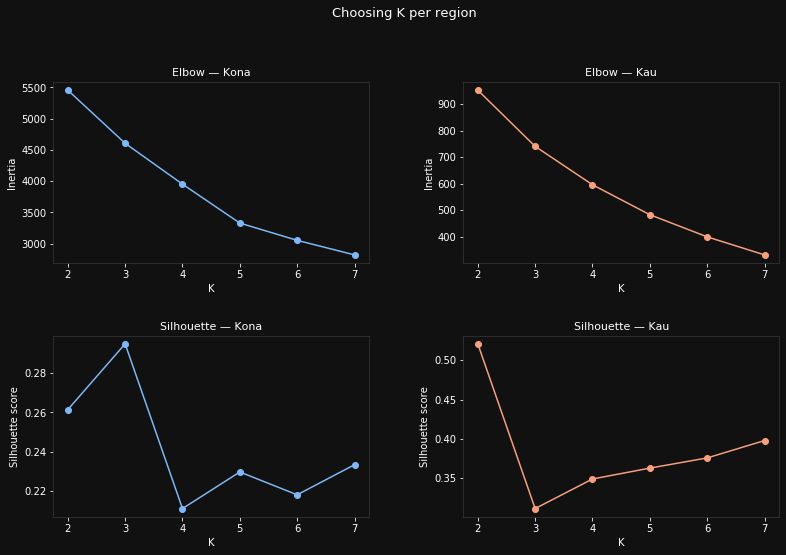

In [3]:
# ── Elbow + silhouette: Kona (left) vs Ka'u (right) ───────────────────────────
KS = range(2, 8)
region_data = {'kona': Xs_dict['kona'], 'kau': Xs_dict['kau']}
best_k = {}

fig, axes = plt.subplots(2, 2, figsize=(13, 8),
                         gridspec_kw={'hspace':0.4,'wspace':0.3})
fig.patch.set_facecolor(BG)

for col_idx, reg in enumerate(['kona', 'kau']):
    Xs = region_data[reg]
    inertias, sil_scores = [], []
    for k in KS:
        km = KMeans(n_clusters=k, random_state=42, n_init=20)
        labels = km.fit_predict(Xs)
        inertias.append(km.inertia_)
        sil_scores.append(silhouette_score(Xs, labels))
    best_k[reg] = list(KS)[np.argmax(sil_scores)]

    for row_idx, (vals, ylabel, title) in enumerate([
        (inertias,   'Inertia',         f'Elbow — {reg.capitalize()}'),
        (sil_scores, 'Silhouette score', f'Silhouette — {reg.capitalize()}'),
    ]):
        ax = axes[row_idx, col_idx]
        ax.set_facecolor(BG)
        ax.tick_params(colors='#222222')
        for spine in ax.spines.values(): spine.set_edgecolor('#cccccc')
        color = '#7eb8f7' if reg == 'kona' else '#f7a07e'
        ax.plot(list(KS), vals, 'o-', color=color)
        ax.set_xlabel('K', color='#222222')
        ax.set_ylabel(ylabel, color='#222222')
        ax.set_title(title, color='#222222', fontsize=11)

    print(f'{reg.capitalize()}: best silhouette K={best_k[reg]}  score={max(sil_scores):.3f}')

fig.suptitle('Choosing K per region', color='#222222', fontsize=13, y=1.01)
plt.savefig(f'{IMG}/08_elbow.png', dpi=150, bbox_inches='tight', facecolor=BG)
plt.show()


In [4]:
# ── Fit K-means (adjust K per region if desired) ──────────────────────────────
K = {'kona': best_k['kona'], 'kau': best_k['kau']}

# Override if you want a specific K
# K = {'kona': 3, 'kau': 2}

kms     = {}
cluster_cols = {}

for reg, sub in [('kona', kona_df), ('kau', kau_df)]:
    km = KMeans(n_clusters=K[reg], random_state=42, n_init=20)
    labels = km.fit_predict(Xs_dict[reg])
    kms[reg] = km
    cluster_cols[reg] = labels
    print(f'{reg.capitalize()} K={K[reg]}:')
    for k in range(K[reg]):
        print(f'  cluster {k}: {(labels==k).sum()} cells')
    print()


Kona K=3:
  cluster 0: 219 cells
  cluster 1: 31 cells
  cluster 2: 8 cells

Kau K=2:
  cluster 0: 52 cells
  cluster 1: 7 cells



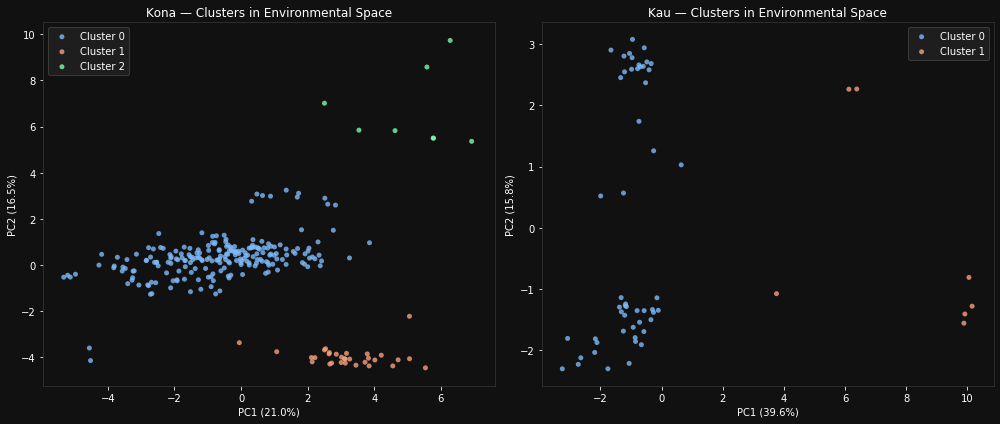

In [5]:
# ── PCA 2D scatter colored by cluster ─────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.patch.set_facecolor(BG)

for ax, reg, sub in zip(axes, ['kona', 'kau'], [kona_df, kau_df]):
    pca = PCA(n_components=2, random_state=42)
    Z   = pca.fit_transform(Xs_dict[reg])
    labels = cluster_cols[reg]

    ax.set_facecolor(BG)
    ax.tick_params(colors='#222222')
    for spine in ax.spines.values(): spine.set_edgecolor('#cccccc')

    for k in range(K[reg]):
        mask = labels == k
        ax.scatter(Z[mask,0], Z[mask,1], color=CLUSTER_COLORS[k],
                   s=25, alpha=0.8, edgecolors='none', label=f'Cluster {k}')

    ax.set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.1%})', color='#222222')
    ax.set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.1%})', color='#222222')
    ax.set_title(f'{reg.capitalize()} — Clusters in Environmental Space', color='#222222', fontsize=12)
    _leg = ax.legend(facecolor='white', edgecolor='#cccccc')
    for _t in _leg.get_texts(): _t.set_color('#222222')

plt.tight_layout()
plt.savefig(f'{IMG}/08_pca_clusters.png', dpi=150, bbox_inches='tight', facecolor=BG)
plt.show()


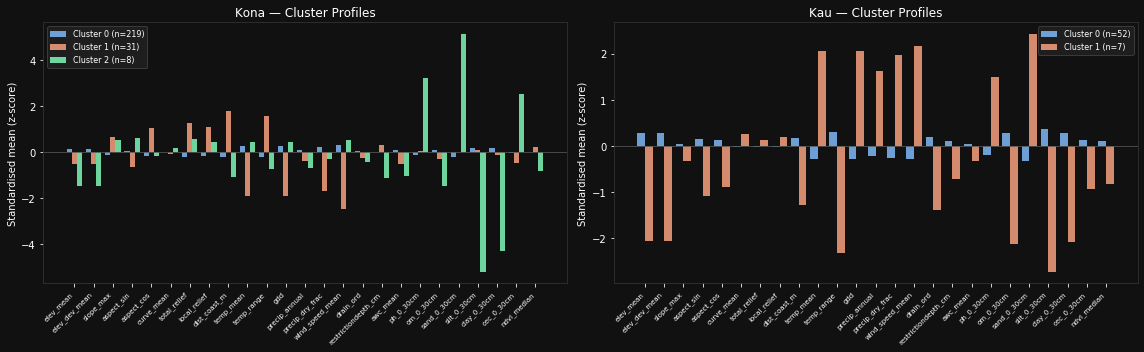

In [6]:
# ── Cluster profiles (z-scores) ───────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 5))
fig.patch.set_facecolor(BG)

for ax, reg, sub in zip(axes, ['kona', 'kau'], [kona_df, kau_df]):
    labels = cluster_cols[reg]
    Xs     = Xs_dict[reg]
    k_val  = K[reg]

    profile_z = np.array([Xs[labels==k].mean(axis=0) for k in range(k_val)])

    ax.set_facecolor(BG)
    ax.tick_params(colors='#222222', axis='both')
    for spine in ax.spines.values(): spine.set_edgecolor('#cccccc')

    x = np.arange(len(FEAT_COLS))
    w = 0.8 / k_val
    for k in range(k_val):
        ax.bar(x + k*w, profile_z[k], width=w,
               color=CLUSTER_COLORS[k], alpha=0.85, label=f'Cluster {k} (n={(labels==k).sum()})')

    ax.axhline(0, color='#555555', linewidth=0.8)
    ax.set_xticks(x + w*(k_val-1)/2)
    ax.set_xticklabels(FEAT_COLS, rotation=45, ha='right', fontsize=7, color='#222222')
    ax.set_ylabel('Standardised mean (z-score)', color='#222222')
    ax.set_title(f'{reg.capitalize()} — Cluster Profiles', color='#222222', fontsize=12)
    _leg = ax.legend(facecolor='white', edgecolor='#cccccc', fontsize=8)
    for _t in _leg.get_texts(): _t.set_color('#222222')

plt.tight_layout()
plt.savefig(f'{IMG}/08_cluster_profiles.png', dpi=150, bbox_inches='tight', facecolor=BG)
plt.show()


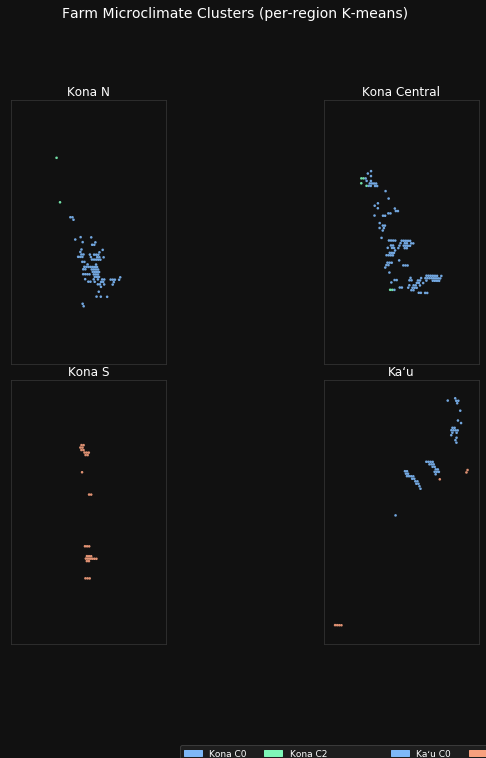

In [7]:
# ── Spatial map: clusters per region ─────────────────────────────────────────
import warnings
warnings.filterwarnings('ignore', message='Geometry is in a geographic CRS')

# Build a combined gdf with cluster labels (0-based within each region)
grid = pd.read_pickle(f'{DATA}/polygons/kona_grid.pkl')

cluster_frames = []
for reg, sub in [('kona', kona_df), ('kau', kau_df)]:
    tmp = sub[['plot_id']].copy()
    tmp['cluster'] = cluster_cols[reg]
    tmp['region']  = reg
    cluster_frames.append(tmp)

cluster_df  = pd.concat(cluster_frames).reset_index(drop=True)
gdf_cl      = gpd.GeoDataFrame(grid.merge(cluster_df, on='plot_id'),
                                geometry='geometry', crs='EPSG:4326')

with warnings.catch_warnings():
    warnings.simplefilter('ignore')
    cx = gdf_cl.geometry.centroid.x
    cy = gdf_cl.geometry.centroid.y

kona   = gdf_cl[cx < SPLIT_LON]
kau    = gdf_cl[cx >= SPLIT_LON]
kona_cy = cy[kona.index]
lat_min, lat_max = kona_cy.min(), kona_cy.max()
cut1 = lat_min + (lat_max - lat_min) / 3
cut2 = lat_min + 2 * (lat_max - lat_min) / 3
kona_n = kona[kona_cy >= cut2]
kona_m = kona[(kona_cy >= cut1) & (kona_cy < cut2)]
kona_s = kona[kona_cy < cut1]

ab = kau.total_bounds
span_w = (ab[2]-ab[0]) * 1.15
span_h = (ab[3]-ab[1]) * 1.15

def centroid_b(r):
    b = r.total_bounds; return (b[0]+b[2])/2, (b[1]+b[3])/2

panels = [(kona_n,'Kona N'),(kona_m,'Kona Central'),(kona_s,'Kona S'),(kau,"Kaʻu")]

fig, axes = plt.subplots(2, 2, figsize=(11, 10),
                         gridspec_kw={'hspace':0.06,'wspace':0.04})
fig.patch.set_facecolor(BG)

max_k = max(K.values())
cmap_cl = ListedColormap(CLUSTER_COLORS[:max_k])

for ax, (region, label) in zip(axes.flat, panels):
    rx, ry = centroid_b(region)
    ax.set_facecolor(BG)
    region.plot(ax=ax, column='cluster', cmap=cmap_cl,
                vmin=-0.5, vmax=max_k-0.5,
                legend=False, edgecolor='none', alpha=0.9)
    ax.set_xlim(rx-span_w/2, rx+span_w/2)
    ax.set_ylim(ry-span_h/2, ry+span_h/2)
    ax.set_title(label, fontsize=12, pad=5, color='#222222')
    ax.set_xticks([]); ax.set_yticks([])
    for spine in ax.spines.values(): spine.set_edgecolor('#cccccc')

# Legends per region
kona_patches = [mpatches.Patch(color=CLUSTER_COLORS[k], label=f'Kona C{k}') for k in range(K['kona'])]
kau_patches  = [mpatches.Patch(color=CLUSTER_COLORS[k], label=f"Kaʻu C{k}") for k in range(K['kau'])]
all_patches  = kona_patches + [mpatches.Patch(color='none', label=' ')] + kau_patches
_leg = fig.legend(handles=all_patches, loc='lower center', ncol=max_k+2,
                  facecolor='white', edgecolor='#cccccc', fontsize=9,
                  bbox_to_anchor=(0.45, -0.03))
for _t in _leg.get_texts(): _t.set_color('#222222')

fig.suptitle('Farm Microclimate Clusters (per-region K-means)', color='#222222', fontsize=14, y=1.01)
plt.savefig(f'{IMG}/08_cluster_map.png', dpi=150, bbox_inches='tight', facecolor=BG)
plt.show()


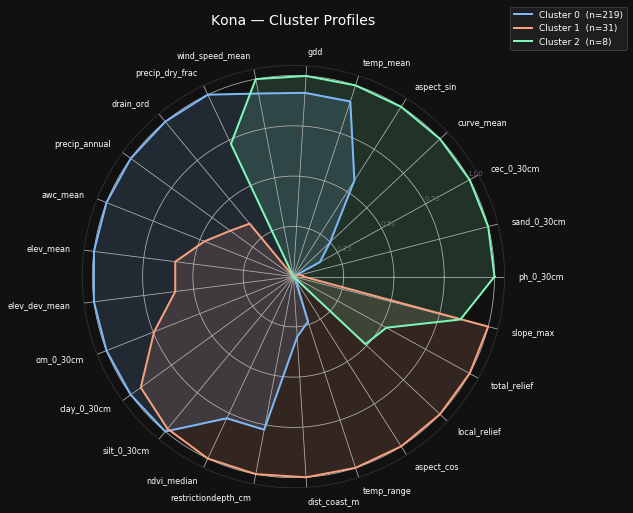

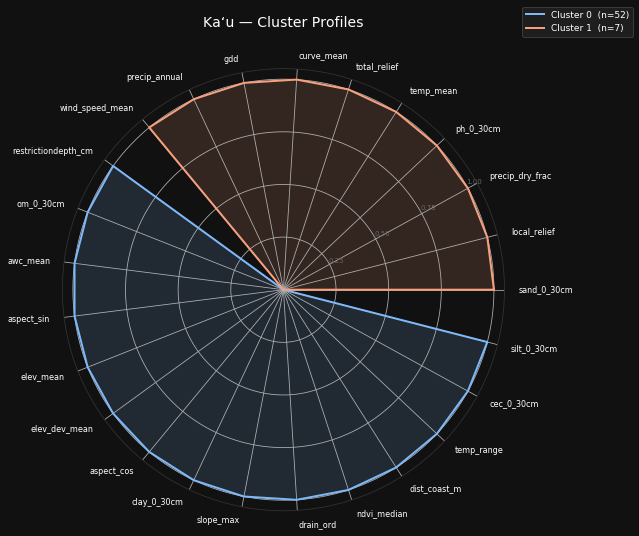

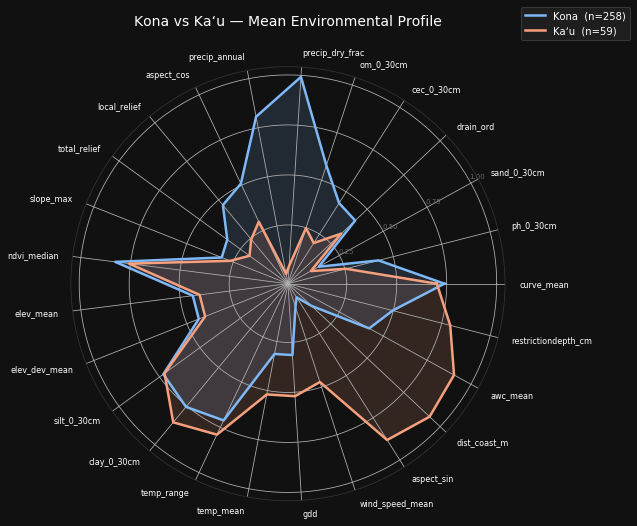

In [8]:
from scipy.cluster.hierarchy import linkage, leaves_list
from scipy.spatial.distance import pdist

# ── Radar plots: within-Kona, within-Kaʻu, and Kona vs Kaʻu ─────────────────

def reorder_spokes(norm_df):
    """Return column order that places correlated features adjacent."""
    mat   = norm_df.fillna(0.5).T.values  # (n_features, n_groups)
    dists = pdist(mat, metric='correlation')
    dists = np.nan_to_num(dists, nan=1.0)
    link  = linkage(dists, method='average', optimal_ordering=True)
    return leaves_list(link)


def radar_plot(means_df, group_labels, colors, title, save_path,
               bg='white', figsize=(9, 9)):
    """
    means_df    : DataFrame — rows = groups, cols = features
    group_labels: list[str] — one per row
    Normalises each feature 0–1, reorders spokes by correlation similarity.
    """
    mn   = means_df.min()
    mx   = means_df.max()
    norm = (means_df - mn) / (mx - mn + 1e-10)
    norm = norm.fillna(0.5)

    # Reorder spokes so correlated features sit adjacent
    order = reorder_spokes(norm)
    norm  = norm.iloc[:, order]
    feats = list(norm.columns)
    n     = len(feats)

    angles  = np.linspace(0, 2 * np.pi, n, endpoint=False).tolist()
    angles += angles[:1]

    fig, ax = plt.subplots(figsize=figsize, subplot_kw=dict(polar=True))
    fig.patch.set_facecolor(bg)
    ax.set_facecolor(bg)
    ax.tick_params(colors='#222222')
    for spine in ax.spines.values():
        spine.set_edgecolor('#cccccc')

    ax.set_xticks(angles[:-1])
    ax.set_xticklabels(feats, color='#222222', fontsize=8)
    for label, angle in zip(ax.get_xticklabels(), angles[:-1]):
        deg = np.degrees(angle)
        label.set_horizontalalignment('left' if (deg <= 90 or deg > 270) else 'right')

    ax.set_rlabel_position(30)
    ax.set_yticks([0.25, 0.5, 0.75, 1.0])
    ax.set_yticklabels(['0.25', '0.50', '0.75', '1.00'], color='#666666', fontsize=7)

    for i, (lbl, col) in enumerate(zip(group_labels, colors)):
        vals  = norm.iloc[i].tolist()
        vals += vals[:1]
        ax.plot(angles, vals, linewidth=2, color=col, label=lbl)
        ax.fill(angles, vals, alpha=0.15, color=col)

    ax.set_title(title, color='#222222', fontsize=14, pad=20)
    leg = ax.legend(loc='upper right', bbox_to_anchor=(1.3, 1.15),
                    facecolor='white', edgecolor='#cccccc', fontsize=9)
    for t in leg.get_texts():
        t.set_color('#222222')
    plt.tight_layout()
    plt.savefig(save_path, dpi=150, bbox_inches='tight', facecolor=bg)
    plt.show()


# ── Radar 1: within-Kona clusters ─────────────────────────────────────────────
kona_means = pd.DataFrame(
    [kona_df[FEAT_COLS].values[cluster_cols['kona'] == k].mean(axis=0)
     for k in range(K['kona'])],
    columns=FEAT_COLS,
)
kona_labels = [f"Cluster {k}  (n={(cluster_cols['kona']==k).sum()})"
               for k in range(K['kona'])]

radar_plot(
    kona_means, kona_labels, CLUSTER_COLORS[:K['kona']],
    title='Kona — Cluster Profiles',
    save_path=f'{IMG}/08_radar_kona.png',
)


# ── Radar 2: within-Kaʻu clusters ─────────────────────────────────────────────
kau_means = pd.DataFrame(
    [kau_df[FEAT_COLS].values[cluster_cols['kau'] == k].mean(axis=0)
     for k in range(K['kau'])],
    columns=FEAT_COLS,
)
kau_labels = [f"Cluster {k}  (n={(cluster_cols['kau']==k).sum()})"
              for k in range(K['kau'])]

radar_plot(
    kau_means, kau_labels, CLUSTER_COLORS[:K['kau']],
    title="Kaʻu — Cluster Profiles",
    save_path=f'{IMG}/08_radar_kau.png',
)


# ── Radar 3: Kona vs Kaʻu — ordered by cell-level feature correlation ─────────
# With only 2 groups, ordering from the full cell-level data is more meaningful
# than ordering from just 2 rows of means.
combined_df  = pd.concat([kona_df[FEAT_COLS], kau_df[FEAT_COLS]])
region_means = pd.DataFrame(
    [kona_df[FEAT_COLS].mean().values,
     kau_df[FEAT_COLS].mean().values],
    columns=FEAT_COLS,
)
mn_comb     = combined_df.min()
mx_comb     = combined_df.max()
region_norm = (region_means - mn_comb) / (mx_comb - mn_comb + 1e-10)
region_norm = region_norm.fillna(0.5)

# Order using cell-level correlations (n=~400 rows, not just 2 group means)
cell_norm = ((combined_df - mn_comb) / (mx_comb - mn_comb + 1e-10)).fillna(0.5)
order3    = reorder_spokes(cell_norm)  # reorder_spokes transposes internally
region_norm = region_norm.iloc[:, order3]
feat_cols_ordered = list(region_norm.columns)

n_feats = len(feat_cols_ordered)
angles  = np.linspace(0, 2 * np.pi, n_feats, endpoint=False).tolist()
angles += angles[:1]

fig, ax = plt.subplots(figsize=(9, 9), subplot_kw=dict(polar=True))
fig.patch.set_facecolor(BG)
ax.set_facecolor(BG)
ax.tick_params(colors='#222222')
for spine in ax.spines.values():
    spine.set_edgecolor('#cccccc')

ax.set_xticks(angles[:-1])
ax.set_xticklabels(feat_cols_ordered, color='#222222', fontsize=8)
for label, angle in zip(ax.get_xticklabels(), angles[:-1]):
    deg = np.degrees(angle)
    label.set_horizontalalignment('left' if (deg <= 90 or deg > 270) else 'right')

ax.set_rlabel_position(30)
ax.set_yticks([0.25, 0.5, 0.75, 1.0])
ax.set_yticklabels(['0.25', '0.50', '0.75', '1.00'], color='#666666', fontsize=7)

for i, (lbl, col) in enumerate([
    (f'Kona  (n={len(kona_df)})', '#7eb8f7'),
    (f"Kaʻu  (n={len(kau_df)})", '#f7a07e'),
]):
    vals  = region_norm.iloc[i].tolist()
    vals += vals[:1]
    ax.plot(angles, vals, linewidth=2.5, color=col, label=lbl)
    ax.fill(angles, vals, alpha=0.15, color=col)

ax.set_title('Kona vs Kaʻu — Mean Environmental Profile',
             color='#222222', fontsize=14, pad=20)
leg = ax.legend(loc='upper right', bbox_to_anchor=(1.3, 1.15),
                facecolor='white', edgecolor='#cccccc', fontsize=10)
for t in leg.get_texts():
    t.set_color('#222222')
plt.tight_layout()
plt.savefig(f'{IMG}/08_radar_regions.png', dpi=150, bbox_inches='tight', facecolor=BG)
plt.show()


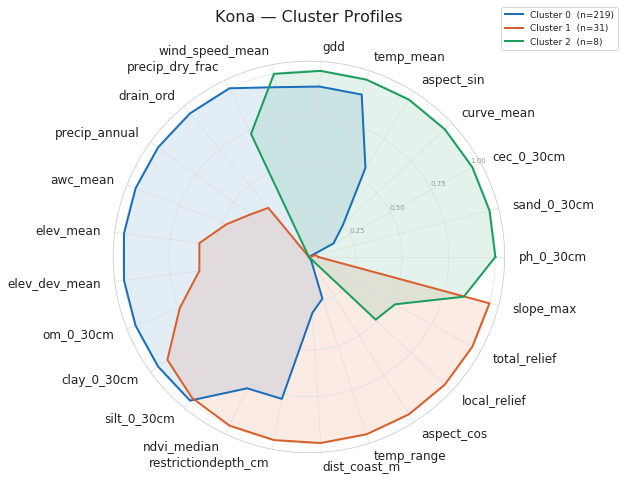

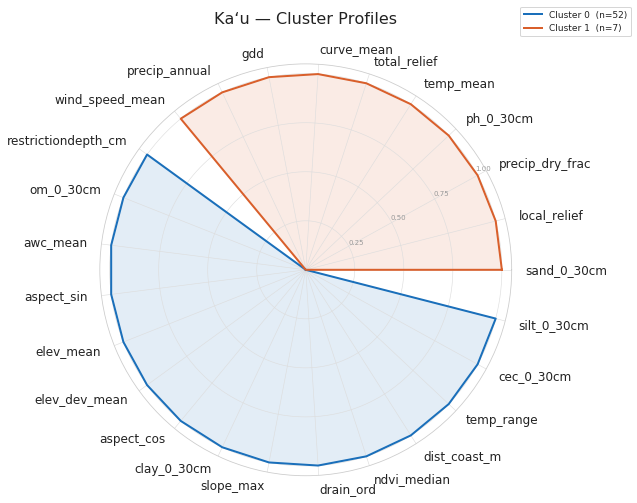

In [13]:
# ── Light-background versions for publishing (LinkedIn / slides) ─────────────
# Same data and spoke order as above — only colours and background change.

CLUSTER_COLORS_LIGHT = ['#1a6fba', '#d95f2b', '#1a9e5c', '#c4831a', '#7b3fb5']

def radar_plot_light(means_df, group_labels, colors, title, save_path, figsize=(9, 9)):
    """Same as radar_plot() but white background for print / social media."""
    mn   = means_df.min()
    mx   = means_df.max()
    norm = (means_df - mn) / (mx - mn + 1e-10)
    norm = norm.fillna(0.5)

    order = reorder_spokes(norm)  # same deterministic order as dark version
    norm  = norm.iloc[:, order]
    feats = list(norm.columns)
    n     = len(feats)

    angles  = np.linspace(0, 2 * np.pi, n, endpoint=False).tolist()
    angles += angles[:1]

    fig, ax = plt.subplots(figsize=figsize, subplot_kw=dict(polar=True))
    fig.patch.set_facecolor('white')
    ax.set_facecolor('white')
    ax.tick_params(colors='#222222')
    for spine in ax.spines.values():
        spine.set_edgecolor('#cccccc')
    ax.grid(color='#dddddd', linewidth=0.6)

    ax.set_xticks(angles[:-1])
    ax.set_xticklabels(feats, color='#222222', fontsize=12)
    for label, angle in zip(ax.get_xticklabels(), angles[:-1]):
        deg = np.degrees(angle)
        label.set_horizontalalignment('left' if (deg <= 90 or deg > 270) else 'right')

    ax.set_rlabel_position(30)
    ax.set_yticks([0.25, 0.5, 0.75, 1.0])
    ax.set_yticklabels(['0.25', '0.50', '0.75', '1.00'], color='#999999', fontsize=7)

    for i, (lbl, col) in enumerate(zip(group_labels, colors)):
        vals  = norm.iloc[i].tolist()
        vals += vals[:1]
        ax.plot(angles, vals, linewidth=2, color=col, label=lbl)
        ax.fill(angles, vals, alpha=0.12, color=col)

    ax.set_title(title, color='#222222', fontsize=16, pad=20)
    leg = ax.legend(loc='upper right', bbox_to_anchor=(1.3, 1.15),
                    facecolor='white', edgecolor='#cccccc', fontsize=9)
    for t in leg.get_texts():
        t.set_color('#222222')
    plt.tight_layout()
    plt.savefig(save_path, dpi=150, bbox_inches='tight', facecolor='white')
    plt.show()


radar_plot_light(
    kona_means, kona_labels, CLUSTER_COLORS_LIGHT[:K['kona']],
    title='Kona — Cluster Profiles',
    save_path=f'{IMG}/08_radar_kona_light.png',
)

radar_plot_light(
    kau_means, kau_labels, CLUSTER_COLORS_LIGHT[:K['kau']],
    title="Kaʻu — Cluster Profiles",
    save_path=f'{IMG}/08_radar_kau_light.png',
)
